In [1]:
!pip install albumentations
!pip install opencv-python

# 0. Library Importation

In [ ]:
import os
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision
import albumentations as A

from sklearn.model_selection import train_test_split

/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


In [3]:
print("All libraries imported successfully")
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("OpenCV version:", cv2.__version__)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Please enable GPU in Kaggle settings.")

!nvidia-smi

All libraries imported successfully
PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
OpenCV version: 4.13.0
CUDA available: False
Device: cpu
GPU is not available. Please enable GPU in Kaggle settings.
/bin/bash: line 1: nvidia-smi: command not found


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 1. Dataset Load

In [ ]:
# ===== PATH =====
BASE_PATH = "/kaggle/input/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction/DRIVE"

train_img_dir = os.path.join(BASE_PATH, "training/images")
train_mask_dir = os.path.join(BASE_PATH, "training/1st_manual")

test_img_dir = os.path.join(BASE_PATH, "test/images")
test_mask_dir = os.path.join(BASE_PATH, "test/1st_manual")

In [6]:
# ===== LOAD TRAIN =====
train_images = sorted(os.listdir(train_img_dir))

train_image_paths = []
train_mask_paths = []

for img_name in train_images:
    img_id = img_name.split('_')[0]
    mask_name = f"{img_id}_manual1.gif"
    
    train_image_paths.append(os.path.join(train_img_dir, img_name))
    train_mask_paths.append(os.path.join(train_mask_dir, mask_name))

In [ ]:
# ===== SPLIT TRAIN - VAL =====
train_image_paths, val_image_paths, train_mask_paths, val_mask_paths = train_test_split(
    train_image_paths, train_mask_paths, 
    test_size=4, 
    random_state=42
)

In [7]:
# ===== LOAD TEST =====
test_images = sorted(os.listdir(test_img_dir))

test_image_paths = []
test_mask_paths = []

for img_name in test_images:
    img_id = img_name.split('_')[0]
    mask_name = f"{img_id}_manual1.gif"
    
    test_image_paths.append(os.path.join(test_img_dir, img_name))
    test_mask_paths.append(os.path.join(test_mask_dir, mask_name))

In [ ]:
# ===== CHECK =====
print("Train:", len(train_image_paths))
print("Test :", len(test_image_paths))
print('Val  :', len(val_image_paths))

Train: 20
Test : 20


In [ ]:
# ===== CHECK SAMPLE INFO =====
sample_img_path = train_image_paths[0]
sample_mask_path = train_mask_paths[0]

img = np.array(Image.open(sample_img_path))
mask = np.array(Image.open(sample_mask_path))

print("\nThông tin sample")
print(f"Shape ảnh gốc : {img.shape}")   # (H, W, 3)
print(f"Shape mask    : {mask.shape}")  # (H, W)


Thông tin sample
Shape ảnh gốc : (584, 565, 3)
Shape mask    : (584, 565)


In [10]:
# ===== CHECK SHAPE & MASK VALUE =====
unique_values = np.unique(mask)
print(f"Giá trị pixel trong mask: {unique_values}") 

Giá trị pixel trong mask: [  0 255]


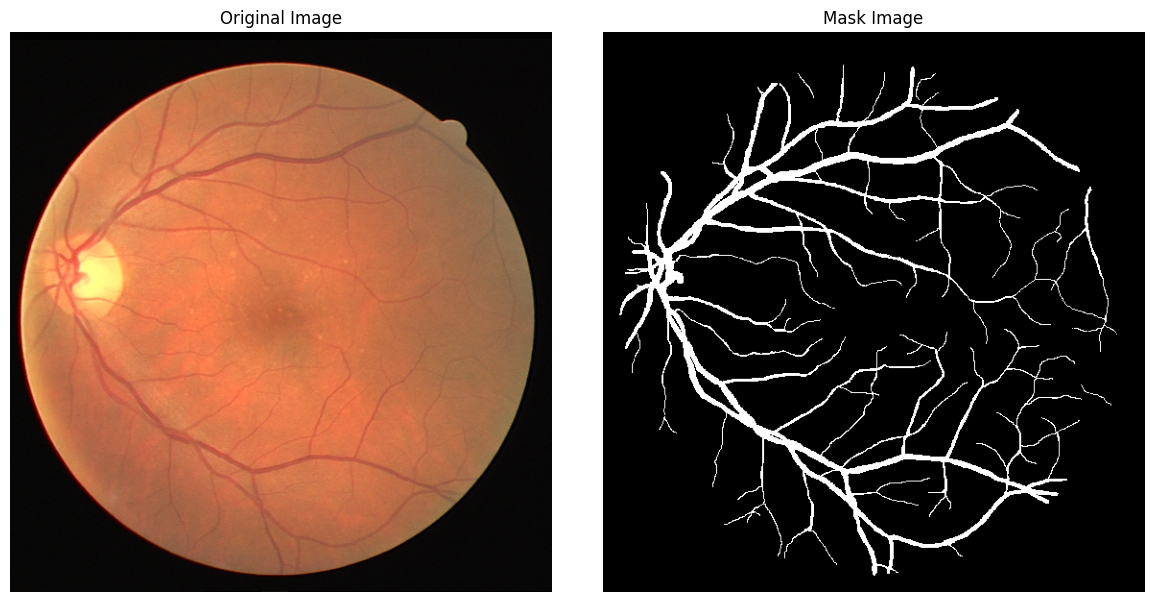

In [11]:
# ===== SHOW BASE + MASK =====
plt.figure(figsize=(12, 6))

# Base
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

# Mask
plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Mask Image")
plt.axis('off')

plt.tight_layout()
plt.show()